In [1]:
"""
7. Perform the following operations using Python on Heart Diseases dataset
A. Data cleaning (Handle null-values, outliers)
B Build any classification model on Heart-disease dataset.
"""

'\n7. Perform the following operations using Python on Heart Diseases dataset\nA. Data cleaning (Handle null-values, outliers)\nB Build any classification model on Heart-disease dataset.\n'

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
df=pd.read_csv('Heart.csv')

In [93]:
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [101]:
df['AHD']=df['AHD'].replace({"Yes":1,"No":0})

In [102]:
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,0


In [40]:
df=df.drop(columns=['Unnamed: 0'],axis=1)

In [41]:
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [42]:
df.isnull().sum()

Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           4
Thal         2
AHD          0
dtype: int64

In [52]:
#count the unique values from the column/
df['Ca'].value_counts()

0.0    180
1.0     65
2.0     38
3.0     20
Name: Ca, dtype: int64

In [44]:
# calc the mode 
mode=df['Ca'].mode()

In [45]:
mode

0    0.0
dtype: float64

In [50]:
#fill the null values with mode 
df['Ca']=df['Ca'].fillna(0.0)

In [53]:

df['Ca'].isnull().sum()

0

In [62]:
#Thal
df['Thal'].value_counts()

normal        168
reversable    117
fixed          18
Name: Thal, dtype: int64

In [63]:
df['Thal'].mode()

0    normal
dtype: object

In [59]:
df['Thal']=df['Thal'].fillna("normal")

In [61]:
df['Thal'].isnull().sum()

0

In [64]:
# Q1 25% of data
# Q3 is 75% of data

# Q3-Q1 is interquartal range

In [65]:
# upper= Q3+1.5*(Q3-Q1)
# lower= Q1-1.5*(Q3-Q1)

<AxesSubplot:>

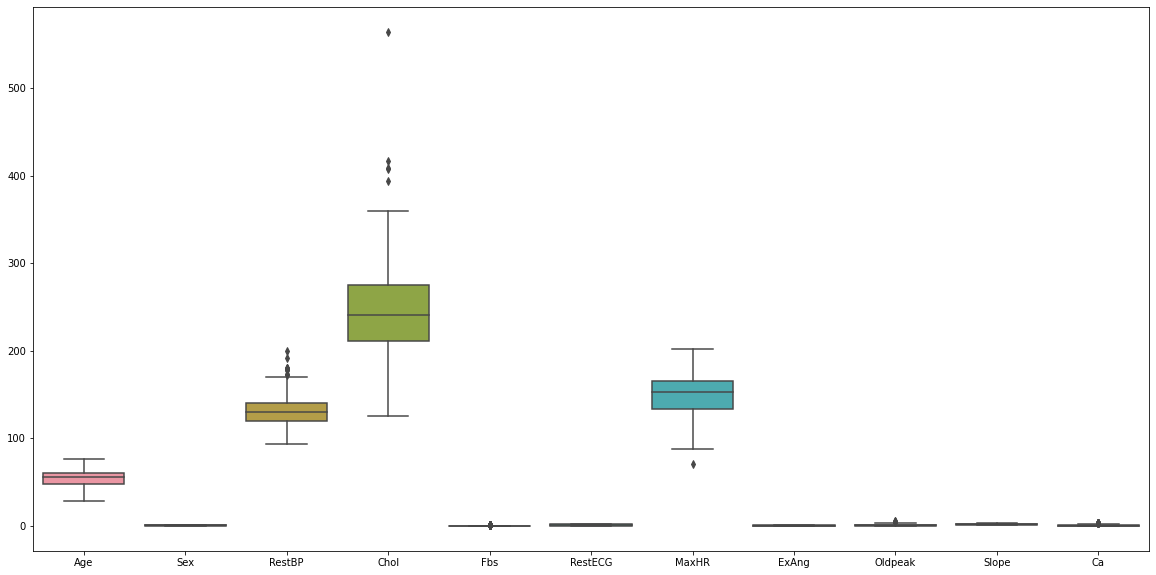

In [72]:
plt.figure(figsize=(20,10))
sns.boxplot(data=df)

In [73]:
#handeling outliers for restbp

In [75]:
#df['RestBP']

In [76]:
q1=np.percentile(df['RestBP'],25)

In [78]:
q3=np.percentile(df['RestBP'],75)

In [81]:
range1=q3-q1

In [84]:
lower_bound=q1-1.5*(q3-q1)

In [86]:
upper_bound=q3+1.5*(q3-q1)

In [88]:
df=df[(df['RestBP']>lower_bound) & (df['RestBP']<upper_bound)]

<AxesSubplot:>

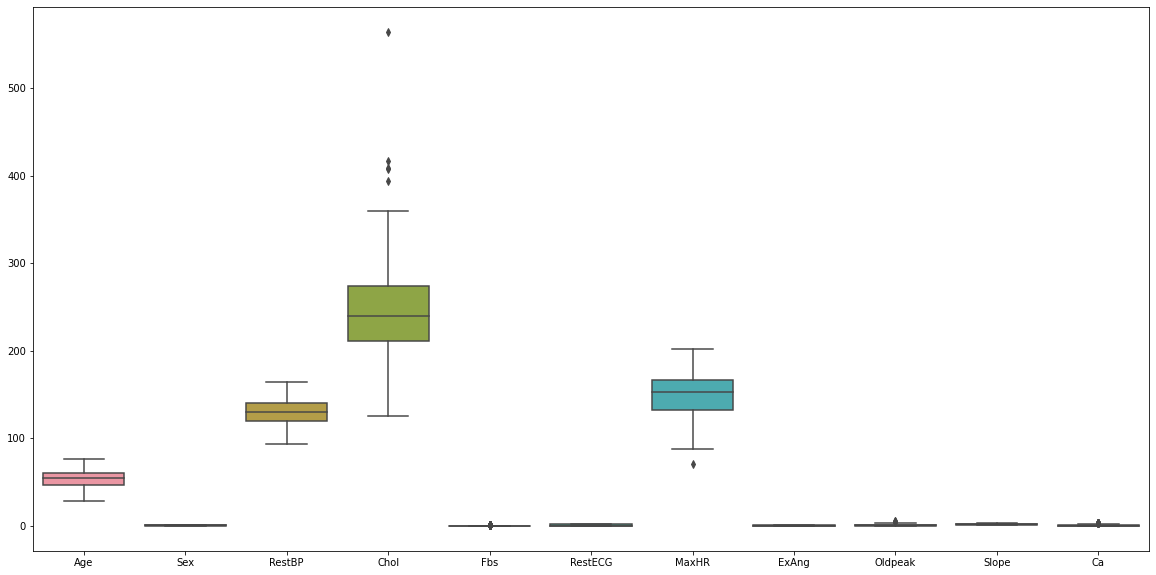

In [89]:
plt.figure(figsize=(20,10))
sns.boxplot(data=df)

In [103]:
#model creation

In [104]:
x=df[['Age']]
y=df[['AHD']]


In [105]:
from sklearn.linear_model import LogisticRegression

In [109]:
model=LogisticRegression()

In [110]:
model.fit(x,y)

c:\users\harshsk\appdata\local\programs\python\python39\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


LogisticRegression()

In [111]:
model.predict([[30]])

array([0], dtype=int64)